一、企业创新与财务绩效

专利数据: (6096734, 20)
财报数据: (76262, 857)
专利申请汇总表形状: (75511, 4)
专利授权汇总表形状: (74473, 6)
           Stkcd    year  发明专利申请量  专利申请总量
0  000001，601318  2010.0        1       1
1  000001，601318  2013.0        2       2
2  000001，601318  2016.0        4       4
3  000001，601318  2017.0        6       6
4  000001，601318  2018.0        1       1
5  000001，601318  2019.0      147     147
6  000001，601318  2020.0      272     272
7  000001，601318  2021.0      357     357
8  000001，601318  2022.0     1905    1905
9  000001，601318  2023.0     1122    1122
           Stkcd    year  发明专利授权量  实用新型授权量  外观专利授权量  专利授权总量
0  000001，601318  2016.0        1        0        0       1
1  000001，601318  2018.0        4        0        0       4
2  000001，601318  2021.0        1        3        0       4
3  000001，601318  2022.0       62        6        0      68
4  000001，601318  2023.0      270        0        0     270
5  000001，601318  2024.0      356        0        0     356
6         000002  2010.0        1  

d:\Python\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")



匹配后面板数据规模：(38109, 33)
经营性质匹配率：96.8%
省份匹配率：96.8%

国企/民企分布：
OWNERSHIPTYPE
私营企业       22063
国营或国有控股    10690
中外合资        3669
其他           218
外商独资         192
集体企业          49
事业单位          14
政府机关          12
Name: count, dtype: int64

东中西部分布：
region
东部    27030
中部     6060
西部     3796
未知     1223
Name: count, dtype: int64

已保存：ex3_1数据合并_面板数据_含省份经营性质.csv

=== 全样本描述性统计 ===
               year      ROE(TTM)         资产负债率      ROA(TTM)    营业毛利率(TTM)  \
count  38109.000000  38109.000000  38109.000000  38109.000000  37829.000000   
mean    2018.044058      0.047798      0.415484      0.043091      0.294108   
std        3.828186      1.106780      0.210187      0.081968      0.184024   
min     2010.000000   -174.894720      0.007080     -1.375046     -3.252881   
25%     2015.000000      0.029526      0.247113      0.014295      0.167366   
50%     2019.000000      0.076508      0.403403      0.042069      0.261849   
75%     2021.000000      0.128440      0.565048      0.077812      0.383

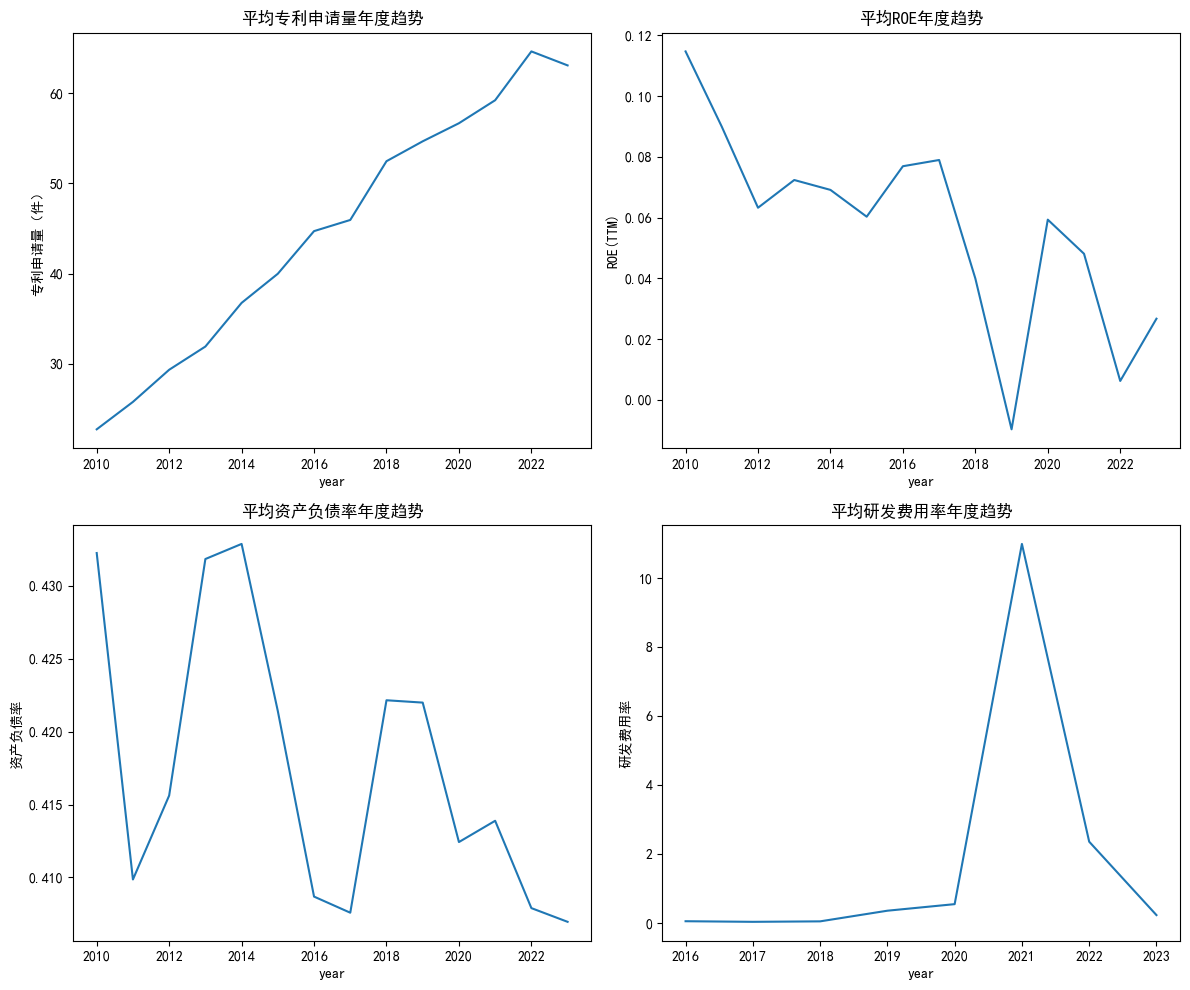

已保存：ex3_1描述性统计_年份趋势可视化


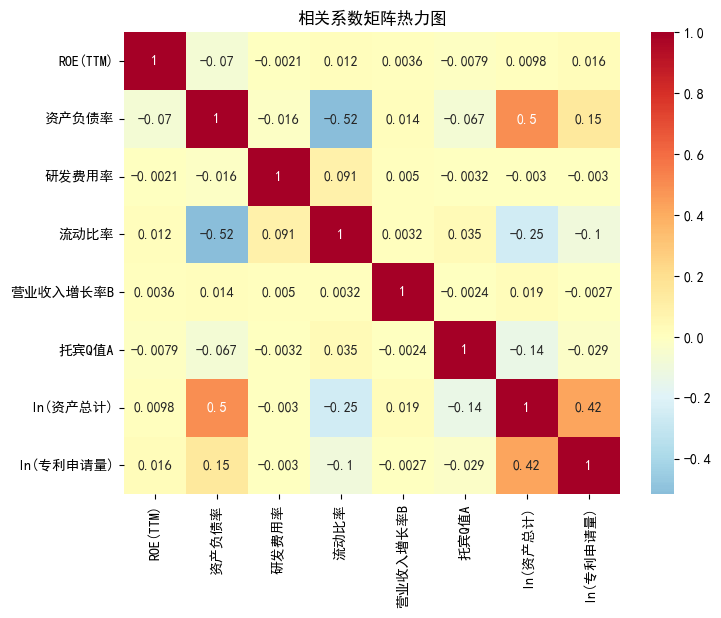

已保存：ex3_1描述性统计_相关系数矩阵热力图

5.2 混合OLS回归（基准模型）
                            OLS Regression Results                            
Dep. Variable:               ROE(TTM)   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     93.36
Date:                Tue, 30 Jun 2026   Prob (F-statistic):          8.03e-135
Time:                        13:27:08   Log-Likelihood:                -26272.
No. Observations:               21920   AIC:                         5.256e+04
Df Residuals:                   21912   BIC:                         5.262e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const   

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.panel import PanelOLS, RandomEffects, compare
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
import statsmodels.api as sm
from scipy import stats

# 设置显示选项
pd.set_option('display.max_columns', None)
plt.rcParams['font.sans-serif'] = ['SimHei']  # 中文显示
plt.rcParams['axes.unicode_minus'] = False

# 一、数据读取与预处理
# 1.1 读取数据
patent_df = pd.read_parquet(r'D:\Limmo\Python数分\实验数据\上市公司专利.parquet')
finance_df = pd.read_parquet(r'D:\Limmo\Python数分\实验数据\上市公司财报.parquet')
print(f"专利数据: {patent_df.shape}")
print(f"财报数据: {finance_df.shape}")

# 1.2 清洗专利表的股票代码，筛选出上市公司
patent_df['Stkcd'] = patent_df['关联股票代码'].astype(str).str.extract(r'\[(.*?)\]', expand=False)

# 1.3 从财报提取年份 
finance_df['year'] = pd.to_datetime(finance_df['Accper']).dt.year

# 1.4 汇总专利申请数据（按企业+申请年份）
# 发明专利申请量（筛选专利类型为"发明专利"且状态为"申请"）
invention_apply = patent_df[
    (patent_df['专利类型'] == '发明专利') & (patent_df['专利状态'] == '申请')
].groupby(['Stkcd', '申请年份']).size().reset_index(name='发明专利申请量')
# 专利申请总量（包括发明专利、实用新型、外观专利的申请）
total_apply = patent_df[patent_df['专利状态'] == '申请'].groupby(
    ['Stkcd', '申请年份']
).size().reset_index(name='专利申请总量')
# 合并
apply_sum = invention_apply.merge(total_apply, on=['Stkcd', '申请年份'], how='left')
apply_sum['发明专利申请量'] = apply_sum['发明专利申请量'].fillna(0).astype(int)
apply_sum.rename(columns={'申请年份': 'year'}, inplace=True)

# 1.5 汇总专利授权数据
grant_df = patent_df[patent_df['专利状态'] == '授权']
grant_pivot = grant_df.pivot_table(index=['Stkcd', '授权年份'], columns='专利类型', aggfunc='size', fill_value=0).reset_index()
grant_pivot.columns.name = None
grant_pivot['外观专利'] = 0
grant_pivot.rename(columns={'授权年份': 'year', '发明专利': '发明专利授权量',
                            '实用新型': '实用新型授权量', '外观专利': '外观专利授权量'}, inplace=True)
grant_pivot['专利授权总量'] = grant_pivot['发明专利授权量'] + grant_pivot['实用新型授权量'] + grant_pivot['外观专利授权量']
print("专利申请汇总表形状:", apply_sum.shape)
print("专利授权汇总表形状:", grant_pivot.shape)
print(apply_sum.head(10))
print(grant_pivot.head(10))

# 二、数据质量检查
# 2.1 缺失值检查
print("\n" + "=" * 80)
print("2.1 缺失值检查")
print("=" * 80)

# 专利表缺失值
print("\n--- 专利表缺失值 ---")
patent_missing = patent_df.isnull().sum()
patent_missing_pct = (patent_missing / len(patent_df)) * 100
patent_missing_df = pd.DataFrame({
    '缺失数量': patent_missing,
    '缺失比例(%)': patent_missing_pct
}).sort_values('缺失比例(%)', ascending=False)
# 只显示有缺失的字段
patent_missing_df = patent_missing_df[patent_missing_df['缺失数量'] > 0]
print(patent_missing_df.head(10))
print(f"\n注：授权年份缺失 {patent_missing_df.loc['授权年份', '缺失数量']} 条，占比 {patent_missing_df.loc['授权年份', '缺失比例(%)']:.2f}%（未授权专利）")

# 财务报表核心字段缺失值
core1_cols = ['Stkcd','ShortName','Accper','Typrep','A001100000','A001212000','A001218000',
             'A001000000','A002101000','A002201000','A002000000','B001101000','B001201000',
             'B001209000','B001210000','B001216000','B001300000','B002000000','B002000101',
             'Indcd','Indnme','F030101A','F030201A','F031501A','F032101B','F032301B',
             'F010101A','F010201A','F011201A','F081002B','F081202B','F081602C','F100103C',
             'F100203C','F100303C','F100401A','F100801A','F100901A','F101001A','F101201B',
             'F050204C','F050304C','F050404C','F050504C','F053301C','F051301C','F051401C',
             'F051501C','F051601C','F051701C','F051801C','F051901C','F053401B','F052001C',
             'F052101C','Nstaff']
finance_core1 = finance_df[core1_cols].copy()
finance_core1.rename(columns={'Stkcd':'证券代码','ShortName':'证券简称','Accper':'统计截止日期','Typrep':'报表类型',
                             'A001100000':'流动资产合计','A001212000':'固定资产净额','A001218000':'无形资产净额',
                             'A001000000':'资产总计','A002101000':'短期借款','A002201000':'长期借款',
                             'A002000000':'负债合计','B001101000':'营业收入','B001201000':'营业成本',
                             'B001209000':'销售费用','B001210000':'管理费用','B001216000':'研发费用',
                             'B001300000':'营业利润','B002000000':'净利润','B002000101':'归属于母公司所有者的净利润',
                             'Indcd':'行业代码','Indnme':'行业名称','F030101A':'流动资产比率','F030201A':'现金资产比率',
                             'F031501A':'流动负债比率','F032101B':'主营业务利润占比','F032301B':'营业利润占比',
                             'F010101A':'流动比率','F010201A':'速动比率','F011201A':'资产负债率','F081002B':'净利润增长率B',
                             'F081202B':'营业利润增长率B','F081602C':'营业收入增长率B','F100103C':'市盈率（PE）TTM',
                             'F100203C':'市销率（PS）TTM','F100303C':'市现率（PCF）TTM','F100401A':'市净率（PB）',
                             'F100801A':'市值A','F100901A':'托宾Q值A','F101001A':'账面市值比A','F101201B':'普通股获利率A',
                             'F050204C':'总资产净利润率(ROA)TTM','F050304C':'流动资产净利润率TTM',
                             'F050404C':'固定资产净利润率TTM','F050504C':'净资产收益率（ROE）TTM',
                             'F053301C':'营业毛利率TTM','F051301C':'营业成本率TTM','F051401C':'营业利润率TTM',
                             'F051501C':'营业净利率TTM','F051601C':'总营业成本率TTM','F051701C':'销售费用率TTM',
                             'F051801C':'管理费用率TTM','F051901C':'财务费用率TTM','F053401B':'研发费用率',
                             'F052001C':'销售期间费用率TTM','F052101C':'成本费用利润率TTM','Nstaff':'员工数目'}, inplace=True)
print("\n--- 财务报表核心字段缺失值 ---")
finance_core_missing = finance_core1.isnull().sum()
finance_core_missing_pct = (finance_core_missing / len(finance_core1)) * 100
finance_missing_df = pd.DataFrame({
    '缺失数量': finance_core_missing,
    '缺失比例(%)': finance_core_missing_pct
}).sort_values('缺失比例(%)', ascending=False)
finance_missing_df = finance_missing_df[finance_missing_df['缺失数量'] > 0]
print(finance_missing_df)

# 2.2 重复值检查
print("\n" + "=" * 80)
print("2.2 重复值检查")
print("=" * 80)

# 专利表重复检查（按专利申请号）
if '专利申请号' in patent_df.columns:
    patent_dup_count = patent_df['专利申请号'].duplicated().sum()
    print(f"\n专利表重复的专利申请号数量: {patent_dup_count}")
else:
    print("\n专利表重复行数: {patent_df.duplicated().sum()}")

# 财务报表重复检查（企业-年度组合）
finance_dup_check = finance_df.groupby(['Stkcd', 'year']).size().reset_index(name='count')
finance_dup_count = (finance_dup_check['count'] > 1).sum()
print(f"财务报表重复的 (Stkcd, year) 组合数量: {finance_dup_count}")

# 2.3 异常值检查
print("\n" + "=" * 80)
print("2.3 异常值检查")
print("=" * 80)

# 资产负债率
if 'F011201A' in finance_df.columns:
    lev = finance_df['F011201A'].dropna()
    print(f"\n资产负债率(F011201A)")
    print(f"范围: [{lev.min():.4f}, {lev.max():.4f}]")
    print(f"均值: {lev.mean():.4f}, 中位数: {lev.median():.4f}")
    print(f"P1: {lev.quantile(0.01):.4f}, P99: {lev.quantile(0.99):.4f}")
    lev_out = ((lev < 0) | (lev > 1)).sum()
    print(f"超出[0,1]范围的记录数: {lev_out} ({lev_out/len(lev)*100:.2f}%)")

# ROE(TTM)
if 'F050504C' in finance_df.columns:
    roe = finance_df['F050504C'].dropna()
    print(f"\nROE(TTM)(F050504C):")
    print(f"范围: [{roe.min():.4f}, {roe.max():.4f}]")
    print(f"均值: {roe.mean():.4f}, 中位数: {roe.median():.4f}")
    print(f"P1: {roe.quantile(0.01):.4f}, P99: {roe.quantile(0.99):.4f}")

# ROA(TTM)
if 'F050204C' in finance_df.columns:
    roa = finance_df['F050204C'].dropna()
    print(f"\nROA(TTM)(F050204C):")
    print(f"范围: [{roa.min():.4f}, {roa.max():.4f}]")
    print(f"均值: {roa.mean():.4f}, 中位数: {roa.median():.4f}")
    print(f"P1: {roa.quantile(0.01):.4f}, P99: {roa.quantile(0.99):.4f}")

# 营业毛利率
if 'F053301C' in finance_df.columns:
    gpm = finance_df['F053301C'].dropna()
    print(f"\n营业毛利率(TTM)(F053301C):")
    print(f"范围: [{gpm.min():.4f}, {gpm.max():.4f}]")
    print(f"均值: {gpm.mean():.4f}, 中位数: {gpm.median():.4f}")
    print(f"P1: {gpm.quantile(0.01):.4f}, P99: {gpm.quantile(0.99):.4f}")

# 年份范围检查
print(f"\n年份范围:")
print(f"专利申请年份范围: {patent_df['申请年份'].min()} - {patent_df['申请年份'].max()}")
print(f"专利授权年份范围: {patent_df['授权年份'].min()} - {patent_df['授权年份'].max()}")

# 2.4 一致性检查
print("\n" + "=" * 80)
print("2.4 一致性检查")
print("=" * 80)

# 股票代码匹配率
patent_stkcd_unique = set(patent_df['Stkcd'].unique())
finance_stkcd_unique = set(finance_df['Stkcd'].unique())
matched_stkcd = patent_stkcd_unique & finance_stkcd_unique

print(f"\n专利表股票代码数：{len(patent_stkcd_unique)}")
print(f"财务报表股票代码数：{len(finance_stkcd_unique)}")
print(f"匹配的股票代码数：{len(matched_stkcd)}")
print(f"专利表匹配率：{len(matched_stkcd)/len(patent_stkcd_unique)*100:.1f}%")
print(f"财务报表匹配率：{len(matched_stkcd)/len(finance_stkcd_unique)*100:.1f}%")

# 会计恒等式检查（资产 = 负债 + 所有者权益）
if 'A001000000' in finance_df.columns and 'A002000000' in finance_df.columns:
    # 计算权益 = 资产 - 负债
    finance_df['计算权益'] = finance_df['A001000000'] - finance_df['A002000000']
    # 所有者权益为负的企业（资不抵债）
    negative_equity = (finance_df['计算权益'] < 0).sum()
    print(f"所有者权益为负的记录数：{negative_equity}（{negative_equity/len(finance_df)*100:.2f}%）")
    print("注：资产不抵债的企业所有者权益为负，属正常情况")

print("\n" + "=" * 80)
print("数据质量检查完成")
print("=" * 80)

# 三、数据合并与面板数据构建
# 3.1 选取财报核心字段
core_cols = ['Stkcd', 'ShortName', 'Accper', 'year', 'Indnme', 'F050504C', 'F011201A', 
              'F050204C', 'F053301C', 'F053401B', 'F010101A', 'F081602C', 'F100901A', 
              'F101001A', 'A001000000', 'A002000000', 'Nstaff']
finance_core = finance_df[core_cols].copy()
finance_core.rename(columns={'F050504C':'ROE(TTM)','F011201A':'资产负债率','F050204C':'ROA(TTM)',
                             'F053301C':'营业毛利率(TTM)','F053401B':'研发费用率','F010101A':'流动比率',
                             'F081602C':'营业收入增长率B','F100901A':'托宾Q值A','F101001A':'账面市值比A',
                             'A001000000':'资产总计','A002000000':'负债合计','Nstaff':'员工数目'},inplace=True)
# 3.2 合并专利与财报
merged = finance_core.merge(apply_sum, on=['Stkcd', 'year'], how='left')
merged = merged.merge(grant_pivot, on=['Stkcd', 'year'], how='left')
patent_cols = ['发明专利申请量', '专利申请总量', '发明专利授权量', '实用新型授权量', '外观专利授权量', '专利授权总量']
merged[patent_cols] = merged[patent_cols].fillna(0)
print("合并后数据规模:", merged.shape)
print(merged.head(5))
all_df = merged.copy()
all_df.to_csv('ex3_1数据合并_完整数据.csv', index=False, encoding='utf-8-sig')
print("已保存: ex3_1数据合并_完整数据.csv")

# 3.3 构建面板数据
merged = merged[(merged['year'] >= 2010) & (merged['year'] <= 2023)]
merged = merged[merged['ROE(TTM)'].notna() & merged['资产总计'].notna()]
merged['ln(资产总计)'] = np.log(merged['资产总计'].replace(0, np.nan))
merged['ln(专利申请量)'] = np.log(merged['专利申请总量'].replace(0, np.nan))
merged['ln(专利授权量)'] = np.log(merged['专利授权总量'].replace(0, np.nan))
merged['ln(发明专利申请量)'] = np.log(merged['发明专利申请量'].replace(0, np.nan))
merged['ln(员工数)'] = np.log(merged['员工数目'].replace(0, np.nan))
merged = merged.dropna(subset=['ln(资产总计)', 'ln(专利申请量)'])

panel_df = merged.copy()
print(f"面板数据规模：{panel_df.shape}")
print(f"企业数量：{panel_df['Stkcd'].nunique()}")
print(f"年份范围：{panel_df['year'].min()} - {panel_df['year'].max()}")
print(f"行业数量：{panel_df['Indnme'].nunique()}")
print("\n核心变量缺失情况:")
core_vars = ['ROE(TTM)', 'ln(专利申请量)', 'ln(资产总计)', '资产负债率', 'ln(员工数)']
for var in core_vars:
    if var in panel_df.columns:
        missing_pct = panel_df[var].isnull().sum() / len(panel_df) * 100
        print(f"  {var}: {missing_pct:.2f}% 缺失")
# 保存面板数据
panel_df.to_csv('ex3_1数据合并_面板数据.csv', index=False, encoding='utf-8-sig')
print("已保存: ex3_1数据合并_面板数据.csv")

# 摘要1：数据规模
summary_scale = pd.DataFrame({
    '指标': ['专利原始数据行数','财报原始数据行数','合并后完整数据行数','合并后完整数据列数','面板数据行数', '面板数据列数','企业数量','年份范围','行业数量','省份数量'],
    '数值': [
        patent_df.shape[0],
        finance_df.shape[0],
        merged.shape[0],
        merged.shape[1],
        panel_df.shape[0],
        panel_df.shape[1],
        panel_df['Stkcd'].nunique() if 'Stkcd' in panel_df.columns else 'N/A',
        f"{panel_df['year'].min()} - {panel_df['year'].max()}" if 'year' in panel_df.columns else 'N/A',
        panel_df['Indnme'].nunique() if 'Indnme' in panel_df.columns else 'N/A',
        panel_df['PROVINCE'].nunique() if 'PROVINCE' in panel_df.columns else 'N/A'
    ]
})
# 摘要2：年份分布
year_dist = panel_df.groupby('year').size().reset_index(name='样本量') if 'year' in panel_df.columns else pd.DataFrame()
# 摘要3：行业分布（前20）
industry_dist = panel_df['Indnme'].value_counts().head(20).reset_index() if 'Indnme' in panel_df.columns else pd.DataFrame()
if not industry_dist.empty:
    industry_dist.columns = ['行业名称', '样本量']
# 摘要4：缺失值统计
core_vars_check = ['ROE(TTM)', '发明专利申请量', '专利申请总量', '发明专利授权量', 
                   '实用新型授权量', '资产负债率', '流动比率', '研发费用率', 
                   '营业收入增长率B', '资产总计', '员工数目']
missing_stats = []
for var in core_vars_check:
    if var in panel_df.columns:
        missing_pct = panel_df[var].isnull().sum() / len(panel_df) * 100
        missing_stats.append({
            '变量名': var,
            '缺失数量': panel_df[var].isnull().sum(),
            '缺失比例(%)': round(missing_pct, 2)
        })
missing_df = pd.DataFrame(missing_stats)
# 摘要5：描述统计
desc_vars = ['ROE(TTM)', '专利申请总量', '资产负债率', '研发费用率']
desc_available = [v for v in desc_vars if v in panel_df.columns]
desc_stats = panel_df[desc_available].describe().round(4) if desc_available else pd.DataFrame()
# 合并摘要
lines = []
# 一、数据规模摘要
lines.append('一、数据规模摘要')
# 手动写表头和数据
lines.append('指标,数值')
for _, row in summary_scale.iterrows():
    lines.append(f"{row['指标']},{row['数值']}")
lines.append('')  # 分隔空行
# 二、年份分布
if not year_dist.empty:
    lines.append('二、年份分布')
    lines.append('year,样本量')
    for _, row in year_dist.iterrows():
        lines.append(f"{row['year']},{row['样本量']}")
    lines.append('')
# 三、行业分布
if not industry_dist.empty:
    lines.append('三、行业分布（前20）')
    lines.append('行业名称,样本量')
    for _, row in industry_dist.iterrows():
        # 行业名称中可能有逗号，加引号处理
        industry_name = row['行业名称'].replace('"', '""')
        lines.append(f'"{industry_name}",{row["样本量"]}')
    lines.append('')
# 四、缺失值统计
if not missing_df.empty:
    lines.append('四、核心变量缺失情况')
    lines.append('变量名,缺失数量,缺失比例(%)')
    for _, row in missing_df.iterrows():
        lines.append(f"{row['变量名']},{row['缺失数量']},{row['缺失比例(%)']}")
    lines.append('')
# 五、描述统计
if not desc_stats.empty:
    lines.append('五、核心变量描述统计')
    # 获取统计指标名称
    stats_names = desc_stats.index.tolist()
    cols = desc_stats.columns.tolist()
    lines.append(f"统计量,{','.join(cols)}")
    for stat in stats_names:
        values = [str(desc_stats.loc[stat, col]) for col in cols]
        lines.append(f"{stat},{','.join(values)}")
# 写入文件
with open('ex3_1数据合并_统计摘要.csv', 'w', encoding='utf-8-sig') as f:
    f.write('\n'.join(lines))
print("已保存: ex3_1数据合并_统计摘要.csv")

# 3.4 匹配公司信息
trd_co = pd.read_excel(r'D:\Limmo\Python数分\实验数据\国泰安数据更新(仅供华南理工大学使用)\TRD_Co.xlsx', dtype={'Stkcd': str})
merged = merged.merge(trd_co[['Stkcd', 'PROVINCE', 'OWNERSHIPTYPE']], on='Stkcd', how='left')
merged['is_soe'] = merged['OWNERSHIPTYPE'].apply(lambda x: 1 if x == '国营或国有控股' else 0)
merged['is_private'] = merged['OWNERSHIPTYPE'].apply(lambda x: 1 if x == '私营企业' else 0)

# 定义地区划分函数
def classify_region(province):
    east = ['北京市', '天津市', '河北省', '上海市', '江苏省', '浙江省', '福建省', 
            '山东省', '广东省', '海南省', '辽宁省', '广西壮族自治区', '香港特别行政区']
    central = ['山西省', '内蒙古自治区', '吉林省', '黑龙江省', '安徽省', '江西省', '河南省', '湖北省', '湖南省']
    west = ['重庆市', '四川省', '贵州省', '云南省', '西藏自治区', '陕西省', '甘肃省', 
            '青海省', '宁夏回族自治区', '新疆维吾尔自治区']
    if province in east:
        return '东部'
    elif province in central:
        return '中部'
    elif province in west:
        return '西部'
    else:
        return '未知'
merged['region'] = merged['PROVINCE'].apply(classify_region)

panel_df1 = merged.copy()
print(f"\n匹配后面板数据规模：{panel_df1.shape}")
# 经营性质匹配率
match_rate = panel_df1['OWNERSHIPTYPE'].notna().sum() / len(panel_df1) * 100
print(f"经营性质匹配率：{match_rate:.1f}%")
# 省份匹配率
province_match_rate = panel_df1['PROVINCE'].notna().sum() / len(panel_df1) * 100
print(f"省份匹配率：{province_match_rate:.1f}%")
# 国企/民企分布
print("\n国企/民企分布：")
ownership_dist = panel_df1['OWNERSHIPTYPE'].value_counts()
print(ownership_dist)
# 东中西部分布
print("\n东中西部分布：")
region_dist = panel_df1['region'].value_counts()
print(region_dist)

# 3.5 保存产出
panel_df1.to_csv('ex3_1数据合并_面板数据_含省份经营性质.csv', index=False, encoding='utf-8-sig')
print("\n已保存：ex3_1数据合并_面板数据_含省份经营性质.csv")

# 四、描述性统计
# 4.1 全样本描述统计
desc = panel_df.describe()
print("\n=== 全样本描述性统计 ===")
print(desc)
desc.to_csv('ex3_1描述性统计_全样本.csv')
print('已保存：ex3_1描述性统计_全样本')

# 4.2 行业分组统计
top_industries = panel_df['Indnme'].value_counts().head(10).index
industry_stats = panel_df[panel_df['Indnme'].isin(top_industries)].groupby('Indnme').agg({
    'ROE(TTM)': 'mean', '资产负债率': 'mean', '研发费用率': 'mean',
    '专利申请总量': 'mean', 'ln(资产总计)': 'mean', 'Stkcd': 'count'
}).rename(columns={'Stkcd': '样本量'})
print("\n=== 按行业分组的描述性统计（前10大行业） ===")
print(top_industries)
industry_stats.to_csv('ex3_1描述性统计_行业分组.csv')
print('已保存：ex3_1描述性统计_行业分组')

# 4.3 年份趋势可视化
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
trend_data = panel_df.groupby('year').agg({
    '专利申请总量': 'mean', 'ROE(TTM)': 'mean', '资产负债率': 'mean', '研发费用率': 'mean'
})
trend_data['专利申请总量'].plot(ax=axes[0,0], title='平均专利申请量年度趋势', ylabel='专利申请量（件）')
trend_data['ROE(TTM)'].plot(ax=axes[0,1], title='平均ROE年度趋势', ylabel='ROE(TTM)')
trend_data['资产负债率'].plot(ax=axes[1,0], title='平均资产负债率年度趋势', ylabel='资产负债率')
trend_data['研发费用率'].plot(ax=axes[1,1], title='平均研发费用率年度趋势', ylabel='研发费用率')
plt.tight_layout()
plt.savefig('ex3_1描述性统计_年份趋势可视化.png')
plt.show()
print('已保存：ex3_1描述性统计_年份趋势可视化')

# 4.4 相关系数矩阵
corr_vars = ['ROE(TTM)', '资产负债率', '研发费用率', '流动比率', '营业收入增长率B',
             '托宾Q值A', 'ln(资产总计)', 'ln(专利申请量)']
corr_matrix = panel_df[corr_vars].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0)
plt.title('相关系数矩阵热力图')
plt.savefig('ex3_1描述性统计_相关系数矩阵热力图.png')
plt.show()
print('已保存：ex3_1描述性统计_相关系数矩阵热力图')

# 五、面板数据回归分析
# 5.1 准备回归数据
reg_df = panel_df[['Stkcd', 'year', 'ROE(TTM)', 'ln(专利申请量)', '资产负债率',
                   'ln(资产总计)', '流动比率', '研发费用率', 'ln(员工数)', '营业收入增长率B']].dropna()
reg_df = reg_df.set_index(['Stkcd', 'year'])

# 5.2 混合OLS
y = reg_df['ROE(TTM)']
X = sm.add_constant(reg_df.drop('ROE(TTM)', axis=1))
ols_model = sm.OLS(y, X).fit()
print("\n" + "="*60)
print('5.2 混合OLS回归（基准模型）')
print("="*60)
print(ols_model.summary())

# 5.3 固定效应模型
fe_model = PanelOLS(reg_df['ROE(TTM)'], reg_df.drop('ROE(TTM)', axis=1), entity_effects=True).fit()
print("\n" + "="*60)
print('5.3 个体固定效应模型')
print("="*60)
print(fe_model)

# 5.4 随机效应模型
re_model = RandomEffects(reg_df['ROE(TTM)'], reg_df.drop('ROE(TTM)', axis=1)).fit()
print("\n" + "="*60)
print('5.4 随机效应模型')
print("="*60)
print(re_model)

# 5.5 模型检验
# F检验（个体效应显著性）
print("\n--- 5.5.1 F检验（个体效应 vs 混合OLS）---")
# 获取企业数量和观测数
n_firm = reg_df.index.get_level_values('Stkcd').nunique()
n_obs = len(reg_df)
n_vars = len(ols_model.params) - 1  # 解释变量个数
# F检验统计量
r2_ols = ols_model.rsquared
r2_fe = fe_model.rsquared
f_stat = ((r2_fe - r2_ols) / (n_firm - 1)) / ((1 - r2_fe) / (n_obs - n_firm - n_vars))
f_pvalue = 1 - stats.f.cdf(f_stat, n_firm - 1, n_obs - n_firm - n_vars)
print(f"F统计量：{f_stat:.4f}")
print(f"p值：{f_pvalue:.6f}")
if f_pvalue < 0.05:
    print(f"结论：拒绝H0，个体效应显著，不应使用混合OLS。")
else:
    print(f"结论：接受H0，个体效应不显著，应使用混合OLS。")

# BP LM检验（随机效应 vs 混合OLS）
print("\n--- 5.5.2 BP LM检验（随机效应 vs 混合OLS）---")
from statsmodels.stats.diagnostic import het_breuschpagan
bp_stat, bp_pvalue, _, _ = het_breuschpagan(ols_model.resid, ols_model.model.exog)
print(f"BP LM统计量：{bp_stat:.4f}")
print(f"p值：{bp_pvalue:.6f}")
if bp_pvalue < 0.05:
    print(f"结论：拒绝H0，随机效应显著，不应使用混合OLS。")
else:
    print(f"结论：接受H0，随机效应不显著，应使用混合OLS。")

# Hausman检验（固定效应 vs 随机效应）
print("\n--- 5.5.3 Hausman检验（固定效应 vs 随机效应）---")
# 确保变量顺序一致
common_vars = ['ln(专利申请量)', '资产负债率', 'ln(资产总计)', '流动比率', '研发费用率', 'ln(员工数)', '营业收入增长率B']
b_fe = fe_model.params[common_vars]
b_re = re_model.params[common_vars]
# 计算协方差矩阵差
cov_diff = fe_model.cov.loc[common_vars, common_vars] - re_model.cov.loc[common_vars, common_vars]
beta_diff = b_fe - b_re
# Hausman统计量
hausman_stat = beta_diff.T @ np.linalg.inv(cov_diff) @ beta_diff
hausman_p = 1 - stats.chi2.cdf(hausman_stat, len(beta_diff))
dof = len(beta_diff)
print(f"Hausman统计量：{hausman_stat:.4f}")
print(f"自由度：{dof}")
print(f"p值：{hausman_p:.6f}")
if hausman_p < 0.05:
    print(f"结论：拒绝H0，应使用固定效应模型(FE)。")
else:
    print(f"结论：接受H0，应使用随机效应模型(RE)。")

# 最终模型选择
print("\n--- 最终模型选择 ---")
if f_pvalue < 0.05:
    if hausman_p < 0.05:
        print("   推荐使用：双向固定效应模型（Two-way Fixed Effects）")
        print("   理由：F检验表明存在个体效应，Hausman检验支持固定效应优于随机效应")
    else:
        print("   推荐使用：随机效应模型（Random Effects）")
        print("   理由：F检验表明存在个体效应，但Hausman检验支持随机效应")
else:
    print("   推荐使用：混合OLS模型（Pooled OLS）")
    print("   理由：F检验表明不存在显著的个体效应")

# 5.6 双向固定效应
fe_time_model = PanelOLS(reg_df['ROE(TTM)'], reg_df.drop('ROE(TTM)', axis=1),
                         entity_effects=True, time_effects=True).fit()
print("\n" + "="*60)
print('5.6 双向固定模型')
print("="*60)
print(fe_time_model)

# 5.7 模型比较
# 获取所有变量的并集
all_vars = set()
for model in [ols_model, re_model, fe_model, fe_time_model]:
    if hasattr(model, 'params'):
        all_vars.update(model.params.index)
# 排除常数项，并排序
all_vars = sorted([v for v in all_vars if v != 'const'])

# 构建结果表格
results_rows = []
for var in all_vars:
    row = {'变量': var}
    
    # OLS
    if var in ols_model.params.index:
        row['OLS系数'] = ols_model.params[var]
        row['OLS_p值'] = ols_model.pvalues[var]
    else:
        row['OLS系数'] = ''
        row['OLS_p值'] = ''
    
    # RE
    if var in re_model.params.index:
        row['RE系数'] = re_model.params[var]
        row['RE_p值'] = re_model.pvalues[var]
    else:
        row['RE系数'] = ''
        row['RE_p值'] = ''
    
    # FE
    if var in fe_model.params.index:
        row['FE系数'] = fe_model.params[var]
        row['FE_p值'] = fe_model.pvalues[var]
    else:
        row['FE系数'] = ''
        row['FE_p值'] = ''
    
    # 双向FE
    if var in fe_time_model.params.index:
        row['双向FE系数'] = fe_time_model.params[var]
        row['双向FE_p值'] = fe_time_model.pvalues[var]
    else:
        row['双向FE系数'] = ''
        row['双向FE_p值'] = ''
    
    results_rows.append(row)

# 添加常数项
const_row = {'变量': '常数项'}
if 'const' in ols_model.params.index:
    const_row['OLS系数'] = ols_model.params['const']
    const_row['OLS_p值'] = ols_model.pvalues['const']
results_rows.insert(0, const_row)

results_df = pd.DataFrame(results_rows)

# 保存到Excel
with pd.ExcelWriter('ex3_1回归结果对比分析.xlsx', engine='openpyxl') as writer:
    table1 = results_df[['变量', 'OLS系数', 'OLS_p值', 'RE系数', 'RE_p值']]
    table1.to_excel(writer, sheet_name='OLS vs 随机效应', index=False)
    table2 = results_df[['变量', 'RE系数', 'RE_p值', 'FE系数', 'FE_p值']]
    table2.to_excel(writer, sheet_name='随机效应 vs 固定效应', index=False)
    table3 = results_df[['变量', 'FE系数', 'FE_p值', '双向FE系数', '双向FE_p值']]
    table3.to_excel(writer, sheet_name='固定效应结果', index=False)
print("\n已保存：ex3_1回归结果对比分析.xlsx")
print(f"  表一：OLS回归 vs 随机效应（{len(table1)}行）")
print(f"  表二：随机效应 vs 固定效应（{len(table2)}行）")
print(f"  表三：固定效应结果（{len(table3)}行）")

# 六、异质性分析
# 6.1 所有制分组
soe_df = panel_df1[panel_df1['is_soe'] == 1]
private_df = panel_df1[panel_df1['is_private'] == 1]

def run_fe_subset(subset, name):
    reg_sub = subset[['Stkcd', 'year', 'ROE(TTM)', 'ln(专利申请量)', '资产负债率',
                      'ln(资产总计)', '流动比率', '研发费用率', 'ln(员工数)', '营业收入增长率B']].dropna()
    reg_sub = reg_sub.set_index(['Stkcd', 'year'])
    model = PanelOLS(reg_sub['ROE(TTM)'], reg_sub.drop('ROE(TTM)', axis=1), entity_effects=True, time_effects=True).fit()
    print(f"\n=== {name}双向固定效应回归 ===")
    print(model)
    return model

print("\n" + "=" * 80)
print("6.1 按所有制分组的固定效应回归")
print("=" * 80)
print(f"国企样本量：{len(soe_df)}，企业数：{soe_df['Stkcd'].nunique()}")
soe_res = run_fe_subset(soe_df, '国营或国有控股')

print(f"\n民企样本量：{len(private_df)}，企业数：{private_df['Stkcd'].nunique()}")
private_res = run_fe_subset(private_df, '私营企业')

# 6.2 地区分组
east_df = panel_df1[panel_df1['region'] == '东部']
central_df = panel_df1[panel_df1['region'] == '中部']
west_df = panel_df1[panel_df1['region'] == '西部']

print("\n" + "=" * 80)
print("6.2 按地区分组的固定效应回归")
print("=" * 80)
print(f"东部样本量：{len(east_df)}，企业数：{east_df['Stkcd'].nunique()}")
east_res = run_fe_subset(east_df, '东部')

print(f"\n中部样本量：{len(central_df)}，企业数：{central_df['Stkcd'].nunique()}")
central_res = run_fe_subset(central_df, '中部')

print(f"\n西部样本量：{len(west_df)}，企业数：{west_df['Stkcd'].nunique()}")
west_res = run_fe_subset(west_df, '西部')

# 6.3 分组结果汇总
group_results = pd.DataFrame({
    '分组': ['国营或国有控股', '私营企业', '东部', '中部', '西部'],
    'ln(专利申请量)系数': [soe_res.params['ln(专利申请量)'], private_res.params['ln(专利申请量)'],
                         east_res.params['ln(专利申请量)'], central_res.params['ln(专利申请量)'],
                         west_res.params['ln(专利申请量)']],
    'p值': [soe_res.pvalues['ln(专利申请量)'], private_res.pvalues['ln(专利申请量)'],
           east_res.pvalues['ln(专利申请量)'], central_res.pvalues['ln(专利申请量)'],
           west_res.pvalues['ln(专利申请量)']],
    'R2': [soe_res.rsquared, private_res.rsquared, east_res.rsquared, central_res.rsquared, west_res.rsquared]
})
group_results.to_csv('ex3_1分组回归结果汇总.csv', index=False)
print("\n已保存：ex3_1分组回归结果汇总")
print(group_results)

二、地区知识产权保护与创新产出

百度指数数据规模: (16, 28)
百度指数数据预览:
   year     山东    贵州    江西    重庆   内蒙古    湖北    辽宁    湖南    福建     上海     北京  \
0  2011   5605  3175  3355  3627  2969  4341  4220  4114  4490   5964   9655   
1  2012   5496  3293  3286  3519  2847  4318  4025  4050  4447   5909   9627   
2  2013   6793  4302  4228  4702  3641  5617  5200  5284  5840   7034  10411   
3  2014   9137  5057  6017  6337  5271  7454  6901  7402  7608   9159  12995   
4  2015  10623  6391  6899  7492  6154  8732  7794  8247  8666  11167  15997   

     广西     广东    四川    云南     江苏     浙江    河北   黑龙江    吉林    天津    陕西    甘肃  \
0  3584   8053  4335  3571   6359   7528  4642  3647  3344  3953  4428  2666   
1  3459   7902  4396  3409   6531   6699  4592  3495  3320  3928  4355  2671   
2  4557   9903  5704  4808   7853   7860  5540  4345  4031  5163  5564  3728   
3  5738  13789  7656  6298  10370  10056  7310  5797  5119  6706  7108  4730   
4  6939  16904  9705  7132  12682  12487  8348  6693  6206  7287  8116  5705   

     新疆  

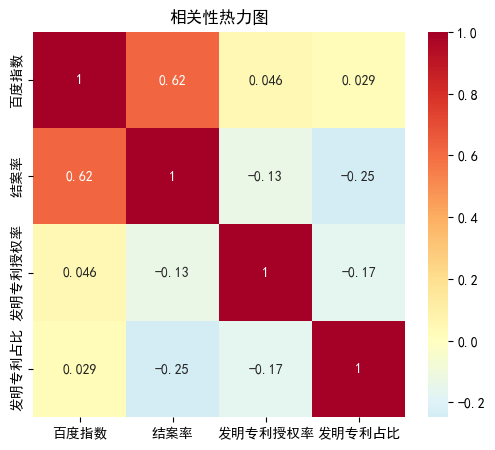

已保存：ex3_2相关性热力图.png

PCA样本量： {350}

PCA解释方差比例:
  PC1: 0.4142 (41.42%)
  PC2: 0.2900 (29.00%)
  PC3: 0.2253 (22.53%)
  PC4: 0.0705 (7.05%)

累计解释方差: [0.41420197 0.70419782 0.92948758 1.        ]

主成分载荷矩阵:
 [[ 0.65928676 -0.1327743   0.41167066 -0.61501156]
 [ 0.71477567 -0.05620412 -0.14382794  0.68209263]
 [-0.04045855  0.7169744   0.65349741  0.23927379]
 [-0.2297821  -0.68202624  0.61869372  0.31505312]]

知识产权保护指数统计：
 count    351.000000
mean      -0.002219
std        1.287841
min       -2.010632
25%       -1.084501
50%       -0.300950
75%        1.029105
max        3.943927
Name: 知识产权保护指数, dtype: float64

全样本描述性统计：
               专利申请总量          百度指数         结案率     发明专利授权率      发明专利占比  \
count     351.000000    351.000000  350.000000  351.000000  351.000000   
mean   114656.572650   8781.062678    0.406933    0.416871    0.356250   
std    155059.023456   4140.730123    0.401003    0.104505    0.110527   
min      3277.000000   2666.000000    0.000000    0.130512    0.138365   
25% 

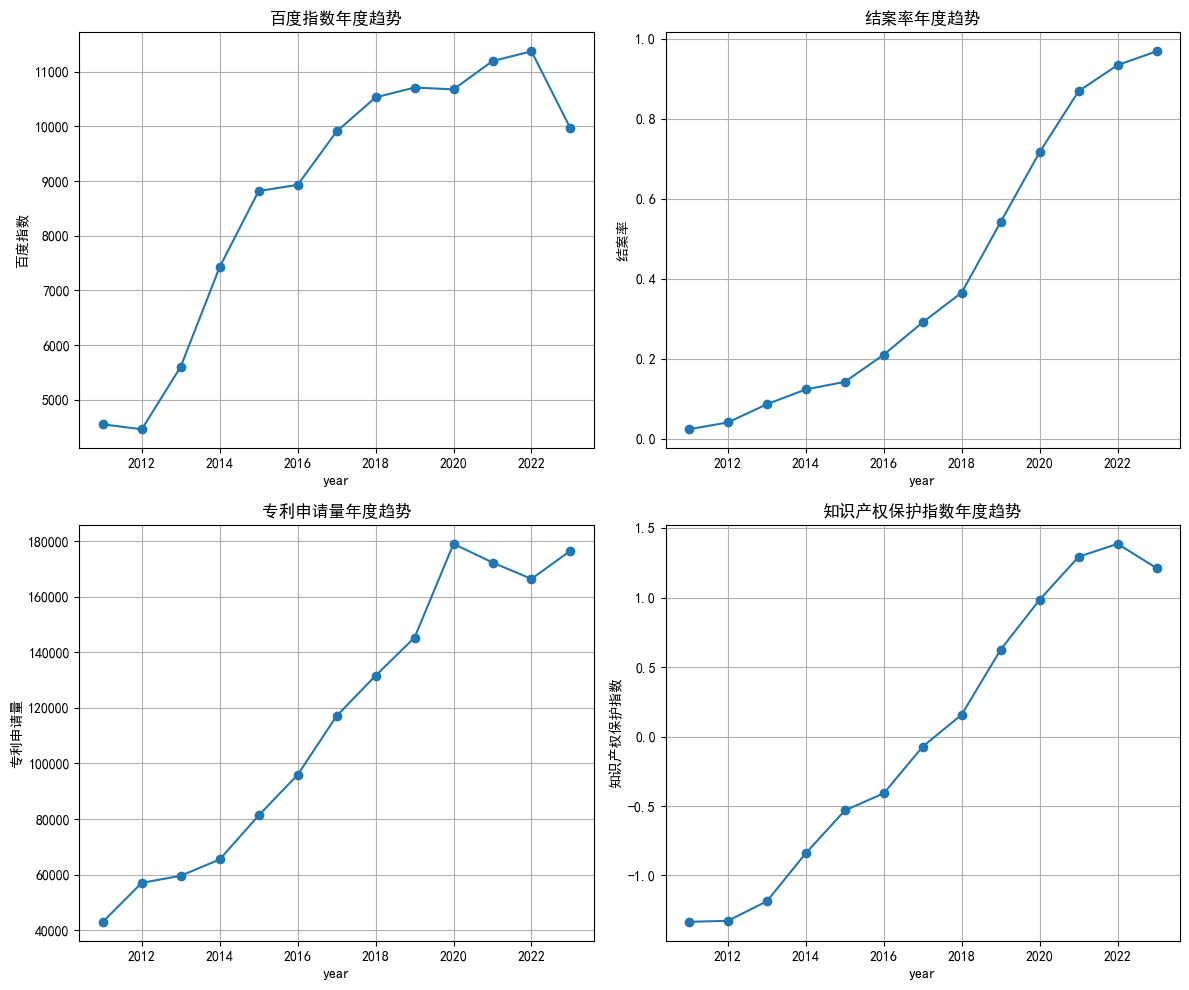

已保存：ex3_2年份趋势可视化.png

回归数据规模： (350, 3)
省份数： 27
年份数： 13

=== 混合OLS回归 ===
                            OLS Regression Results                            
Dep. Variable:              ln(专利申请量)   R-squared:                       0.714
Model:                            OLS   Adj. R-squared:                  0.712
Method:                 Least Squares   F-statistic:                     432.3
Date:                Mon, 29 Jun 2026   Prob (F-statistic):           6.15e-95
Time:                        20:19:34   Log-Likelihood:                -334.80
No. Observations:                 350   AIC:                             675.6
Df Residuals:                     347   BIC:                             687.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects

# 设置显示选项
pd.set_option('display.max_columns', None) # 显示DataFrame所有列
plt.rcParams['font.sans-serif'] = ['SimHei']  # 中文显示
plt.rcParams['axes.unicode_minus'] = False # 显示负号

# 一、数据读取与合并
# 1.1 读取数据
baidu = pd.read_csv('D:/Limmo/Python数分/实验数据/百度指数_年度数据.csv')
case_rate = pd.read_csv('D:/Limmo/Python数分/实验数据/结案率_完整面板数据.csv')
patent_prov = pd.read_csv('D:/Limmo/Python数分/实验数据/佰腾网省级专利数据.csv')

print("百度指数数据规模:", baidu.shape)
print("百度指数数据预览:")
print(baidu.head())
print("\n结案率数据规模:", baidu.shape)
print("结案率数据预览:")
print(case_rate.head())
print("\n专利数据规模:", baidu.shape)
print("专利数据列名：", patent_prov.columns)
print(f"专利数据年份范围：{patent_prov['year'].min()} - {patent_prov['year'].max()}")
print("专利数据预览:")
print(patent_prov.head())

patent_prov.rename(columns={'province': '省份'}, inplace=True)

# 1.2 省份名称标准化
province_map = {
    '山东': '山东省', '江苏': '江苏省', '广东': '广东省', '浙江': '浙江省',
    '北京': '北京市', '上海': '上海市', '福建': '福建省', '安徽': '安徽省',
    '河南': '河南省', '湖北': '湖北省', '湖南': '湖南省', '四川': '四川省',
    '河北': '河北省', '天津': '天津市', '海南': '海南省', '辽宁': '辽宁省',
    '广西': '广西壮族自治区', '山西': '山西省', '新疆':'新疆维吾尔自治区',
    '内蒙古': '内蒙古自治区', '吉林':'吉林省', '云南':'云南省', '江西':'江西省',
    '重庆':'重庆市', '贵州':'贵州省', '黑龙江':'黑龙江省', '西藏':'西藏自治区',
    '陕西':'陕西省', '甘肃':'甘肃省', '青海':'青海省', '宁夏':'宁夏回族自治区', 
}
baidu.rename(columns=province_map, inplace=True)
print('\n百度指数列名转换后；\n', baidu.columns)

# 1.3 宽转长
baidu_long = baidu.melt(id_vars=['year'], var_name='省份', value_name='百度指数')
case_long = case_rate.melt(id_vars=['省份'], var_name='year', value_name='结案率')
case_long['year'] = case_long['year'].astype(int)
print('\n百度指数长格式：\n', baidu_long.head())
print('\n结案率长格式：\n', case_long.head())

# 1.4 合并面板
merged_prov = patent_prov.merge(baidu_long, on=['省份', 'year'], how='left')
merged_prov = merged_prov.merge(case_long, on=['省份', 'year'], how='left')
print('\n合并后面板数据规模：', merged_prov.shape)
print('面板数据预览：\n', merged_prov.head())

# 二、数据清洗与处理
# 2.1 缺失值诊断
print("\n=== 2.1 缺失值诊断 ===")
missing_df = pd.DataFrame({
    '缺失数量': merged_prov.isnull().sum(), 
    '缺失比例(%)': (merged_prov.isnull().sum() / len(merged_prov)) * 100
})
print(missing_df)
print('\n百度指数缺失的省份：', merged_prov[merged_prov['百度指数'].isnull()]['省份'].unique().tolist())
print('结案率缺失的年份：', merged_prov[merged_prov['结案率'].isnull()]['year'].unique().tolist())
merged_prov = merged_prov.dropna(subset=['百度指数']).reset_index(drop=True)
for province in merged_prov['省份'].unique():
    mask = merged_prov['省份'] == province
    # 按年份排序后进行线性插值
    merged_prov.loc[mask, '结案率'] = merged_prov.loc[mask].set_index('year')['结案率']\
        .sort_index().interpolate(method='linear').values
    # 边界值使用前向/后向填充
    merged_prov.loc[mask, '结案率'] = merged_prov.loc[mask, '结案率'].ffill().bfill()
print('补全后缺失数：\n', merged_prov.isnull().sum())

# 2.2 异常值处理
merged_prov['结案率'] = merged_prov['结案率'].replace([np.inf, -np.inf], np.nan).clip(upper=1)
print('\n处理后的结案率：\n', merged_prov['结案率'].describe())

# 2.3 衍生指标
merged_prov['发明专利授权率'] = merged_prov['发明授权'] / merged_prov['发明']
merged_prov['发明专利占比'] = merged_prov['发明'] / (merged_prov['实用新型'] + merged_prov['发明'] + merged_prov['外观设计'] + 1)
merged_prov['ln(专利申请量)'] = np.log(merged_prov['实用新型'] + merged_prov['发明'] + merged_prov['外观设计'] + 1)
merged_prov.loc[merged_prov['发明专利授权率'] > 2, '发明专利授权率'] = np.nan
print('\n衍生指标统计：\n', merged_prov[['发明专利授权率', '发明专利占比', 'ln(专利申请量)']].describe())
merged_prov.insert(2, '专利申请总量', merged_prov['实用新型'] + merged_prov['发明'] + merged_prov['外观设计'])

# 2.4 保存清洗后数据
merged_prov = merged_prov.dropna(subset=['实用新型','发明','发明授权','外观设计']).reset_index(drop=True)
merged_prov.to_csv('ex3_2清洗后面板数据.csv', index=False)
print('已保存：ex3_2清洗后面板数据.csv')

# 三、相关性分析与PCA
# 3.1 相关性分析
pca_vars = ['百度指数', '结案率', '发明专利授权率', '发明专利占比']
pca_data = merged_prov[pca_vars].dropna().reset_index(drop=True)
corr_matrix = pca_data.corr()
print('\n相关系数矩阵：\n', corr_matrix)
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0)
plt.title('相关性热力图')
plt.savefig('ex3_2相关性热力图.png')
plt.show()
print('已保存：ex3_2相关性热力图.png')

# 3.2 主成分分析(PCA)
scaler = StandardScaler()
scaled = scaler.fit_transform(pca_data)
pca = PCA(n_components=4)
pca.fit(scaled)
print('\nPCA样本量：', {len(pca_data)})
print("\nPCA解释方差比例:")
for i, ratio in enumerate(pca.explained_variance_ratio_, 1):
    print(f'  PC{i}: {ratio:.4f} ({ratio*100:.2f}%)')
print("\n累计解释方差:", np.cumsum(pca.explained_variance_ratio_))
print("\n主成分载荷矩阵:\n", pca.components_.T)

# 构建知识产权保护综合指数，添加到面板数据
merged_prov['知识产权保护指数'] = pca.transform(scaler.transform(merged_prov[pca_vars].fillna(0)))[:, 0]
print('\n知识产权保护指数统计：\n', merged_prov['知识产权保护指数'].describe())

# 四、描述性统计
desc_prov = merged_prov[['专利申请总量', '百度指数', '结案率', '发明专利授权率', '发明专利占比', '知识产权保护指数']].describe()
desc_prov.to_csv('ex3_2描述性统计_全样本.csv')
print('\n全样本描述性统计：\n', desc_prov)
print('\n已保存：ex3_2描述性统计_全样本.csv')

# 4.2 年份趋势可视化
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
trend_prov = merged_prov.groupby('year').agg({
    '百度指数': 'mean', '结案率': 'mean', '专利申请总量': 'mean', '知识产权保护指数': 'mean'
})
trend_prov['百度指数'].plot(ax=axes[0,0], title='百度指数年度趋势', ylabel='百度指数', marker='o', grid=True)
trend_prov['结案率'].plot(ax=axes[0,1], title='结案率年度趋势', ylabel='结案率', marker='o', grid=True)
trend_prov['专利申请总量'].plot(ax=axes[1,0], title='专利申请量年度趋势', ylabel='专利申请量', marker='o', grid=True)
trend_prov['知识产权保护指数'].plot(ax=axes[1,1], title='知识产权保护指数年度趋势', ylabel='知识产权保护指数', marker='o', grid=True)
plt.tight_layout()
plt.savefig('ex3_2年份趋势可视化.png')
plt.show()
print('已保存：ex3_2年份趋势可视化.png')

# 五、面板数据回归分析
# 5.1 准备回归数据
reg_prov = merged_prov[['省份', 'year', 'ln(专利申请量)', '百度指数', '结案率']].dropna().reset_index(drop=True)
reg_prov = reg_prov.set_index(['省份', 'year'])
print('\n回归数据规模：', reg_prov.shape)
print('省份数：', reg_prov.index.get_level_values('省份').nunique())
print('年份数：', reg_prov.index.get_level_values('year').nunique())

# 5.2 混合OLS
y = reg_prov['ln(专利申请量)']
X = sm.add_constant(reg_prov[['百度指数', '结案率']])
ols_prov = sm.OLS(y, X).fit()
print('\n=== 混合OLS回归 ===')
print(ols_prov.summary())

# 5.3 固定效应
fe_prov = PanelOLS(reg_prov['ln(专利申请量)'], reg_prov[['百度指数', '结案率']], entity_effects=True).fit()
print('\n=== 固定效应模型 ===')
print(fe_prov)

# 5.4 随机效应
re_prov = RandomEffects(reg_prov['ln(专利申请量)'], reg_prov[['百度指数', '结案率']]).fit()
print('\n=== 随机效应模型 ===')
print(re_prov)

# 5.5 模型检验
print("\n=== 5.5 模型检验 ===")
reg_prov = merged_prov[['省份', 'year', 'ln(专利申请量)', '百度指数', '结案率']].dropna().reset_index(drop=True)
# 定义变量
y = reg_prov['ln(专利申请量)']
X = reg_prov[['百度指数', '结案率']]

# 5.5.1 F检验 判断固定效应模型是否优于混合OLS
print("\n--- F检验（个体效应显著性）---")
X_const = sm.add_constant(X)# 添加常数项
entity_dummies = pd.get_dummies(reg_prov['省份'])# 获取个体虚拟变量
entity_dummies = entity_dummies.astype(float)# 确保 entity_dummies 是数值类型
X_with_entity = pd.concat([X_const, entity_dummies], axis=1)# 合并 - 使用 axis=1
# F检验
ols_with_entity = sm.OLS(y, X_with_entity).fit()
f_test_result = ols_with_entity.f_test(entity_dummies.columns.tolist())
print(f"F统计量: {f_test_result.statistic:.4f}  p值: {f_test_result.pvalue:.4f}")
if f_test_result.pvalue < 0.05:
    print("结论: p < 0.05，拒绝原假设，个体效应显著，固定效应模型优于混合OLS")
else:
    print("结论: p >= 0.05，不拒绝原假设，个体效应不显著，混合OLS更优")

# 5.5.2 Hausman检验：比较固定效应与随机效应模型
print("\n--- Hausman检验（固定效应模型 vs 随机效应模型）---")
reg_panel = merged_prov[['省份', 'year', 'ln(专利申请量)', '百度指数', '结案率']].dropna()
reg_panel = reg_panel.set_index(['省份', 'year'])
reg_panel = reg_panel.astype(float)
y_panel = reg_panel['ln(专利申请量)']
X_panel = reg_panel[['百度指数', '结案率']]
fe_prov = PanelOLS(y_panel, X_panel, entity_effects=True).fit()
re_prov = RandomEffects(y_panel, X_panel).fit()
from scipy import stats
beta_diff = fe_prov.params - re_prov.params
cov_diff = fe_prov.cov - re_prov.cov
hausman_stat = beta_diff.T @ np.linalg.inv(cov_diff) @ beta_diff
hausman_p = 1 - stats.chi2.cdf(hausman_stat, len(beta_diff))
print(f"Hausman统计量: {hausman_stat:.4f}  p值: {hausman_p:.4f}")
print("结论: 固定效应更优" if hausman_p < 0.05 else "结论: 随机效应更优")

# 5.6 回归结果汇总
prov_results = pd.DataFrame({
    '模型': ['混合OLS', '固定效应', '随机效应'],
    '百度指数系数': [ols_prov.params['百度指数'],fe_prov.params['百度指数'],re_prov.params['百度指数']],
    '百度指数p值': [ols_prov.pvalues['百度指数'],fe_prov.pvalues['百度指数'],re_prov.pvalues['百度指数']],
    '结案率系数': [ols_prov.params['结案率'],fe_prov.params['结案率'],re_prov.params['结案率']],
    '结案率p值': [ols_prov.pvalues['结案率'],fe_prov.pvalues['结案率'],re_prov.pvalues['结案率']],
    'R^2': [ols_prov.rsquared, fe_prov.rsquared, re_prov.rsquared]
})
prov_results.to_csv('ex3_2回归结果汇总.csv', index=False)
print('\n回归结果汇总：\n', prov_results)
print('已保存：ex3_2回归结果汇总.csv')

# 六、地区异质性分析
# 6.1 划分东中西部
region_dict = {
    '东部': ['北京市', '天津市', '河北省', '上海市', '江苏省', '浙江省', '福建省', '山东省', '广东省', '海南省', '辽宁省', '广西壮族自治区'],
    '中部': ['山西省', '内蒙古自治区', '吉林省', '黑龙江省', '安徽省', '江西省', '河南省', '湖北省', '湖南省'],
    '西部': ['重庆市', '四川省', '贵州省', '云南省', '西藏自治区', '陕西省', '甘肃省', '青海省', '宁夏回族自治区', '新疆维吾尔自治区']
}
def get_region(prov):
    for r, provs in region_dict.items():
        if prov in provs:
            return r
    return '其他'
merged_prov['region'] = merged_prov['省份'].apply(get_region)

# 6.2 分地区回归
region_results = []
for region in ['东部', '中部', '西部']:
    sub = merged_prov[merged_prov['region'] == region].dropna(subset=['ln(专利申请量)', '百度指数', '结案率'])
    if len(sub) < 10:
        continue
    X = sm.add_constant(sub[['百度指数', '结案率']])
    y = sub['ln(专利申请量)']
    model = sm.OLS(y, X).fit()
    region_results.append({
        '地区': region,
        '样本量': len(sub),
        '省份数': merged_prov[merged_prov['region'] == region]['省份'].nunique(),
        '百度指数系数': model.params['百度指数'],
        '百度指数p值': model.pvalues['百度指数'],
        '结案率系数': model.params['结案率'],
        '结案率p值': model.pvalues['结案率'],
        'R^2': model.rsquared
    })
region_df = pd.DataFrame(region_results)
region_df.to_csv('ex3_2地区异质性回归结果.csv', index=False)
print('\n=== 地区异质性结果汇总 ===\n', region_df)
print('已保存：ex3_2地区异质性回归结果.csv')